## Comparison with GEDI

In [1]:
from scipy.stats import qmc
import numpy as np

import csv
import xarray as xr
import pandas as pd
import os
import netCDF4 as nc4
import sys
import shutil
from tempfile import TemporaryFile                                                                                                                                 
import argparse                                                                                                                                                                                                                                                                                                       
import tempfile 
import random
import re

from PIL import Image
import tifffile
import rasterio
import rioxarray

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from matplotlib import cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.colors import BoundaryNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature


import functions_py.fates_xarray_functions as fa

/global/homes/j/jneedham/.conda/envs/myenv/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Load GEDI

In [2]:
# Load the TIFF with xarray + rasterio
ds = rioxarray.open_rasterio("/global/homes/j/jneedham/gedi/gediv002_rh-95-a0_vf_20190417_20230316_12000m.tif", masked=True).squeeze()
da = ds.isel(band=0)

# Print CRS info
print("CRS:", da.rio.crs)

CRS: EPSG:6933


''

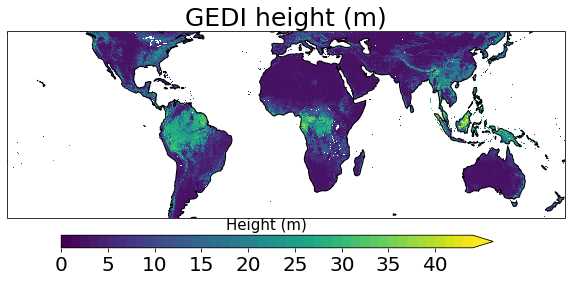

In [3]:
# Create a map projection from the TIFF's native CRS
data_crs = da.rio.crs
data_proj = ccrs.epsg(data_crs.to_epsg())

fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': data_proj},
                        figsize=(10,3.5))

clevs=np.arange(0,45,1)

# Plot the data
cs = da.plot(ax=axs, levels=clevs, cmap='viridis', add_colorbar=False)

# Add map features
axs.set_title("GEDI height (m)", fontsize=25)
axs.coastlines()

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.2, 0.015, 0.6, 0.05])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')   
cbar.ax.set_title(r'Height (m)', fontsize=15)
cbar.ax.tick_params(labelsize=20)
;

### Load FATES

In [4]:
#fates = '/pscratch/sd/j/jneedham/elm_runs/tropical_fb/nocomp_fates_tropical.E1c1a3b9fb7-F5ab1ef10.2025-06-27/run/nocomp_fates_tropical.E1c1a3b9fb7-F5ab1ef10.2025-06-27.2290s.nc'
fates = '/pscratch/sd/j/jneedham/elm_runs/tropical_fb/nocomp_fates_tropical.E1c1a3b9fb7-Fc5271c3f.2025-07-15/run/nocomp_fates_tropical.E1c1a3b9fb7-Fc5271c3f.2025-07-15.2040s.nc'
fates = xr.open_dataset(fates, decode_times=False)

#fates_ctr = '/pscratch/sd/j/jneedham/elm_runs/tropical_fb/nocomp_fates_tropical_controlrun.E1c1a3b9fb7-F5ab1ef10.2025-07-07/run/nocomp_fates_tropical_controlrun.E1c1a3b9fb7-F5ab1ef10.2025-07-07.2290s.nc'
fates_ctr = '/pscratch/sd/j/jneedham/elm_runs/tropical_fb/nocomp_fates_tropical_control.E1c1a3b9fb7-Fc5271c3f.2025-07-16/run/nocomp_fates_tropical_control.E1c1a3b9fb7-Fc5271c3f.2025-07-16.2040s.nc'
fates_ctr = xr.open_dataset(fates_ctr, decode_times=False)

time = fates.variables['time'] / 365.
cohort_size_bins = fates.variables['fates_levscls'][:]
nsizebins = len(cohort_size_bins)

In [5]:
height_ctr = fates_ctr.FATES_CA_WEIGHTED_HEIGHT.mean(dim='time')
height = fates.FATES_CA_WEIGHTED_HEIGHT.mean(dim='time')

In [6]:
height_ctr = fates_ctr.FATES_MEAN_95PCTILE_HEIGHT.mean(dim='time')
height= fates.FATES_MEAN_95PCTILE_HEIGHT.mean(dim='time')


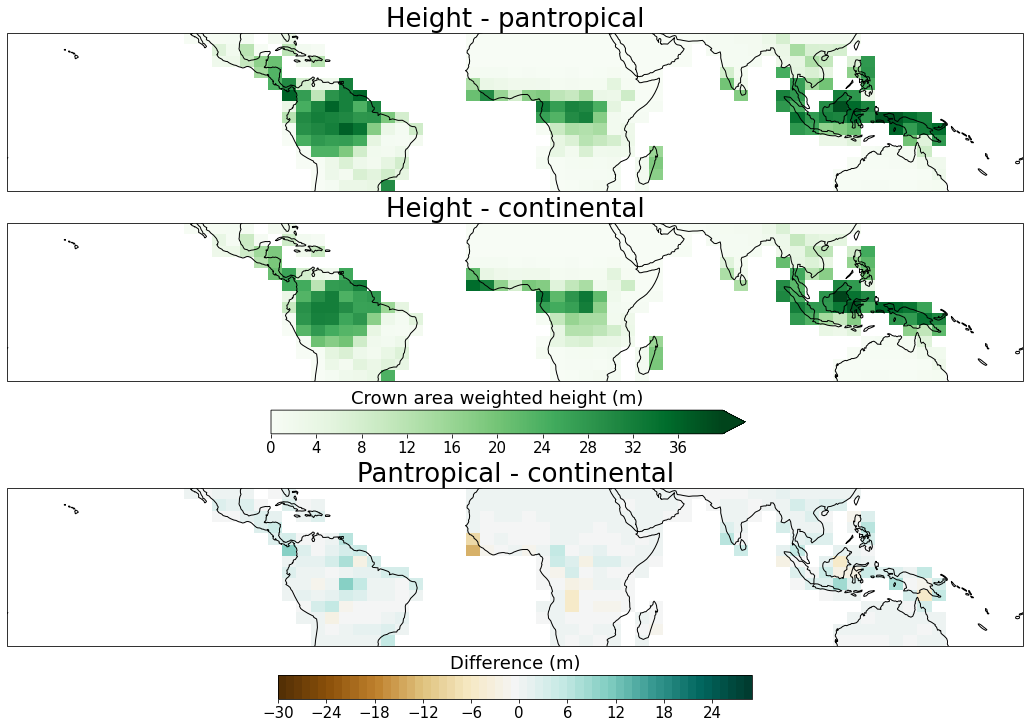

In [7]:
# Define the contour levels to use in plt.contourf
clevs=np.arange(0,40,0.1)
fig, axs = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(18,10), constrained_layout=True)

axs = axs.flatten()

cs= height_ctr.plot(levels=clevs,cmap='Greens', ax=axs[0],add_colorbar=False)
axs[0].set_title('Height - pantropical', size=26)
axs[0].coastlines()

cs= height.plot(levels=clevs,cmap='Greens', ax=axs[1],add_colorbar=False)
axs[1].set_title('Height - continental', size=26)
axs[1].coastlines()

cbar = fig.colorbar(cs, ax=axs[1], location='bottom',shrink=0.6)
cbar.ax.set_title("Crown area weighted height (m)", size=18)
cbar.ax.tick_params(labelsize=15) 

diff = height_ctr - height

clevs=np.arange(-30,30,1)
cs= diff.plot(levels=clevs,cmap='BrBG', ax=axs[2],add_colorbar=False)
axs[2].set_title('Pantropical - continental', size=26)
axs[2].coastlines()

cbar = fig.colorbar(cs, ax=axs[2], location='bottom',shrink=0.6)
cbar.ax.set_title("Difference (m)", size=18)
cbar.ax.tick_params(labelsize=15) 

## Regrid GEDI

We will use reproject_match from the rioxarray library. 
This requires x y dimensions and a grid  mapping  variable with spatial_ref or crs  attribute to be set containing a valid CRS. 
GEDI data already contains  x and y dimensions and CRS EPSG:6933. 
FATES has lat,lon and no CRS information. 
First assign CRS to FATES. 
Rename FATES dimensions. 
Apply reproject_match. 


In [8]:
fates_tmp = fates
fates_tmp.rio.write_crs("epsg:4326", inplace=True)
fates_tmp = fates_tmp.rename({'lon': 'x','lat': 'y'})


In [9]:
fates_ctr_tmp = fates_ctr
fates_ctr_tmp.rio.write_crs("epsg:4326", inplace=True)
fates_ctr_tmp = fates_ctr_tmp.rename({'lon': 'x','lat': 'y'})


In [10]:
# Print CRS info
print("CRS:", fates_tmp.rio.crs)

CRS: EPSG:4326


In [11]:
height_ctr = fates_ctr_tmp.FATES_MEAN_95PCTILE_HEIGHT.mean(dim='time')
height = fates_tmp.FATES_MEAN_95PCTILE_HEIGHT.mean(dim='time')

In [12]:
gedi_reproj = da.rio.reproject_match(height_ctr)

In [13]:
gedi_reproj.coords

Coordinates:
  * x            (x) float32 0.0 5.0 10.0 15.0 20.0 ... 340.0 345.0 350.0 355.0
  * y            (y) float32 -26.0 -22.0 -18.0 -14.0 ... 14.0 18.0 22.0 26.0
    band         int64 1
    spatial_ref  int64 0

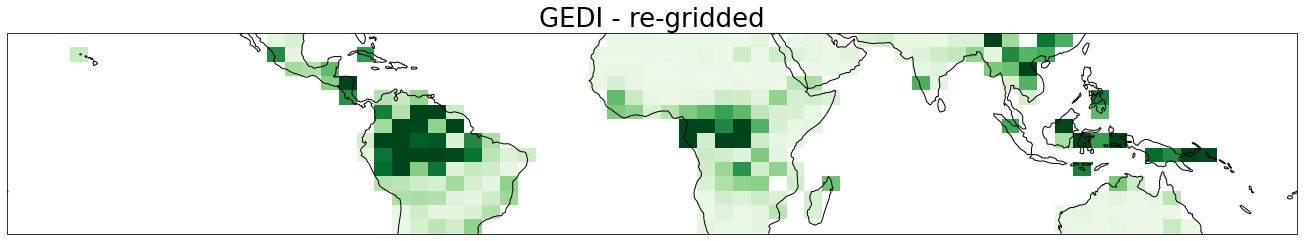

In [14]:
# Define the contour levels to use in plt.contourf
clevs=np.arange(0,25,0.1)
fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(18,4), constrained_layout=True)


cs= gedi_reproj.plot(levels=clevs,cmap='Greens', ax=axs,add_colorbar=False)
axs.set_title('GEDI - re-gridded', size=26)
axs.coastlines()

In [15]:
diff  = gedi_reproj - height
diff_ctr = gedi_reproj - height_ctr

diff_fates = height_ctr - height

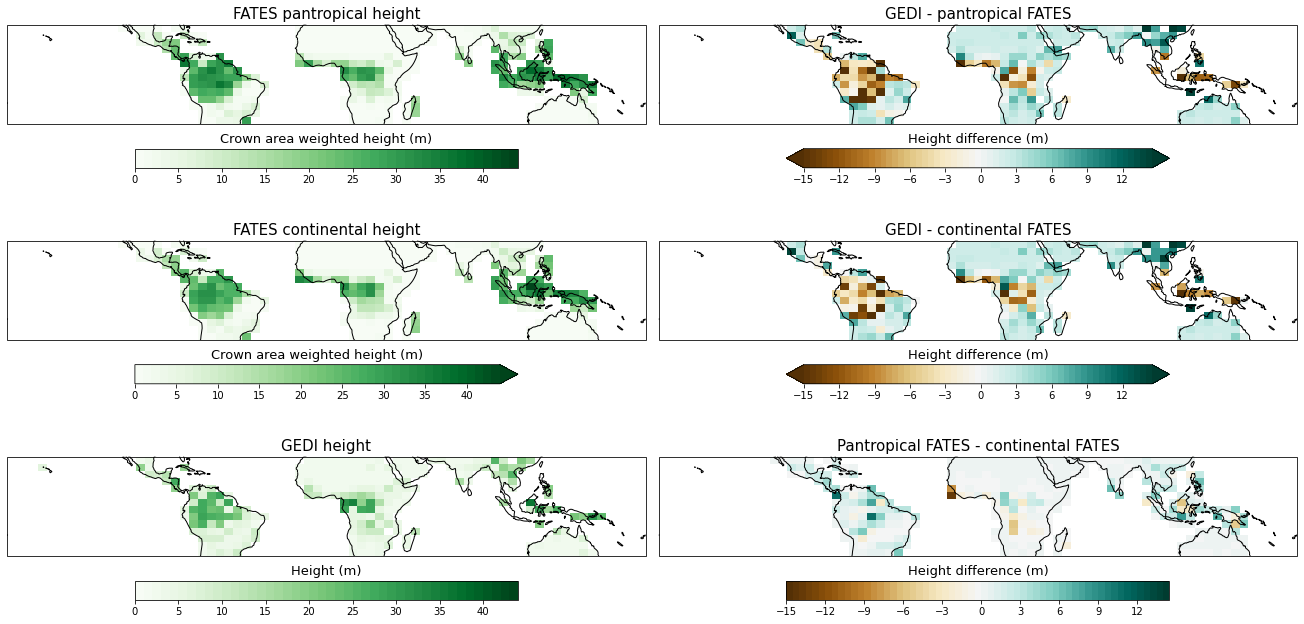

In [16]:
fig, axs = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(18,9),constrained_layout=True)

clevs = np.arange(0.,45,1)
axs=axs.flatten()

cs = height_ctr.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='Greens',
         ax=axs[0], add_colorbar=False)
axs[0].coastlines()
axs[0].set_title('FATES pantropical height', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[0], location='bottom',shrink=0.6)
cbar.ax.set_title("Crown area weighted height (m)", fontsize=13)

cs = height.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='Greens',
         ax=axs[2], add_colorbar=False)
axs[2].coastlines()
axs[2].set_title('FATES continental height', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[2], location='bottom',shrink=0.6)
cbar.ax.set_title("Crown area weighted height (m)", fontsize=13)

cs = gedi_reproj.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='Greens',
         ax=axs[4], add_colorbar=False)
axs[4].coastlines()
axs[4].set_title('GEDI height', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[4], location='bottom',shrink=0.6)
cbar.ax.set_title("Height (m)", fontsize=13)

clevs = np.arange(-15,15,0.5)
cs = diff_ctr.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='BrBG',
         ax=axs[1], add_colorbar=False)
axs[1].coastlines()
axs[1].set_title('GEDI - pantropical FATES', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[1], location='bottom',shrink=0.6)
cbar.ax.set_title("Height difference (m)", fontsize=13)


cs = diff.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='BrBG',
         ax=axs[3], add_colorbar=False)
axs[3].coastlines()
axs[3].set_title('GEDI - continental FATES', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[3], location='bottom',shrink=0.6)
cbar.ax.set_title("Height difference (m)", fontsize=13)

cs = diff_fates.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='BrBG',
         ax=axs[5], add_colorbar=False)
axs[5].coastlines()
axs[5].set_title('Pantropical FATES - continental FATES', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[5], location='bottom',shrink=0.6)
cbar.ax.set_title("Height difference (m)", fontsize=13)

plt.savefig('/global/homes/j/jneedham/tropical-fixed-biog/figs/GEDI_v_FATES_height.png', 
            bbox_inches='tight', facecolor='white')


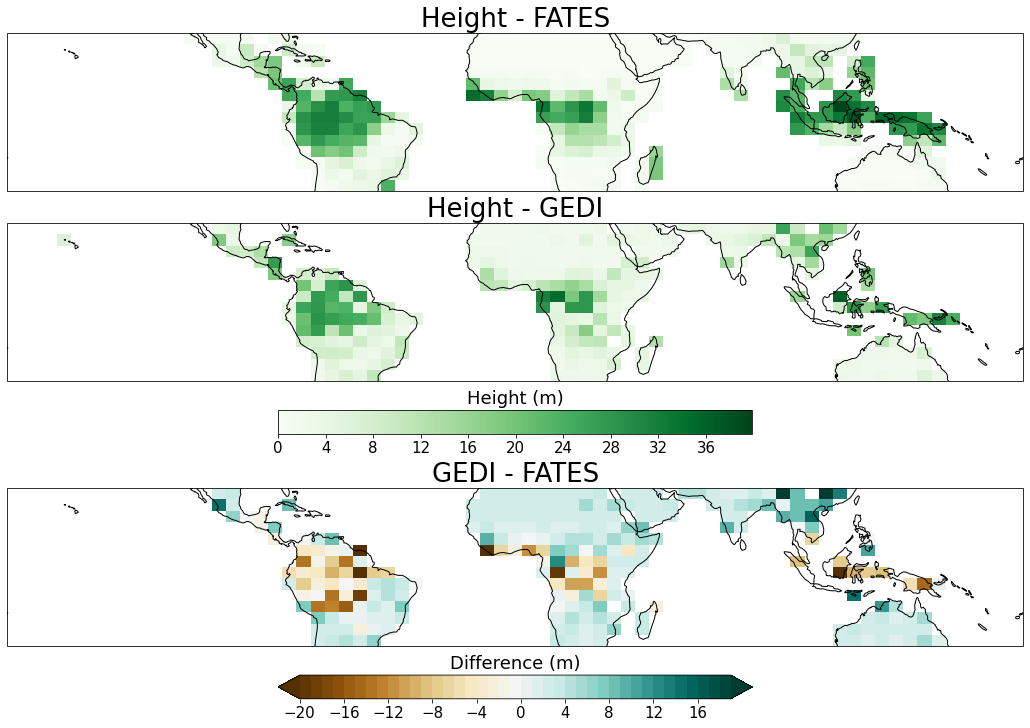

In [17]:
# Define the contour levels to use in plt.contourf
clevs=np.arange(0,40,0.1)
fig, axs = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(18,10), constrained_layout=True)

axs = axs.flatten()

cs= height.plot(levels=clevs,cmap='Greens', ax=axs[0],add_colorbar=False)
axs[0].set_title('Height - FATES', size=26)
axs[0].coastlines()

cs= gedi_reproj.plot(levels=clevs,cmap='Greens', ax=axs[1],add_colorbar=False)
axs[1].set_title('Height - GEDI', size=26)
axs[1].coastlines()

cbar = fig.colorbar(cs, ax=axs[1], location='bottom',shrink=0.6)
cbar.ax.set_title("Height (m)", size=18)
cbar.ax.tick_params(labelsize=15) 

diff  = gedi_reproj - height

clevs=np.arange(-20,20,1)
cs= diff.plot(levels=clevs,cmap='BrBG', ax=axs[2],add_colorbar=False)
axs[2].set_title('GEDI - FATES', size=26)
axs[2].coastlines()

cbar = fig.colorbar(cs, ax=axs[2], location='bottom',shrink=0.6)
cbar.ax.set_title("Difference (m)", size=18)
cbar.ax.tick_params(labelsize=15) 

### AGB - 

In [18]:
# Load the TIFF with xarray + rasterio
ds = rioxarray.open_rasterio("/global/homes/j/jneedham/gedi/gediv002_agbd-a0_vf_20190417_20230316_12000m.tif", masked=True).squeeze()
da = ds.isel(band=0)

# Print CRS info
print("CRS:", da.rio.crs)

CRS: EPSG:6933


''

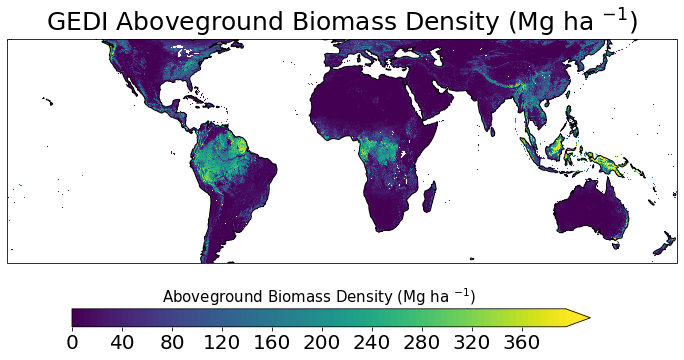

In [19]:
# Create a map projection from the TIFF's native CRS
data_crs = da.rio.crs
data_proj = ccrs.epsg(data_crs.to_epsg())

fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': data_proj},
                        figsize=(12,5))

clevs=np.arange(0,400,5)

# Plot the data
cs = da.plot(ax=axs, levels=clevs, cmap='viridis', add_colorbar=False)

# Add map features
axs.set_title(r"GEDI Aboveground Biomass Density (Mg ha $^{-1}$)", fontsize=25)
axs.coastlines()

# Add a colorbar axis at the bottom of the graph
cbar_ax = fig.add_axes([0.2, 0.015, 0.6, 0.05])

# Draw the colorbar
cbar=fig.colorbar(cs, cax=cbar_ax, orientation='horizontal')   
cbar.ax.set_title(r'Aboveground Biomass Density (Mg ha $^{-1}$)', fontsize=15)
cbar.ax.tick_params(labelsize=20)
;

### FATES AGB

In [20]:
agb_ctr = fates_ctr.FATES_VEGC_ABOVEGROUND.mean(dim='time') *  10
agb = fates.FATES_VEGC_ABOVEGROUND.mean(dim='time') * 10

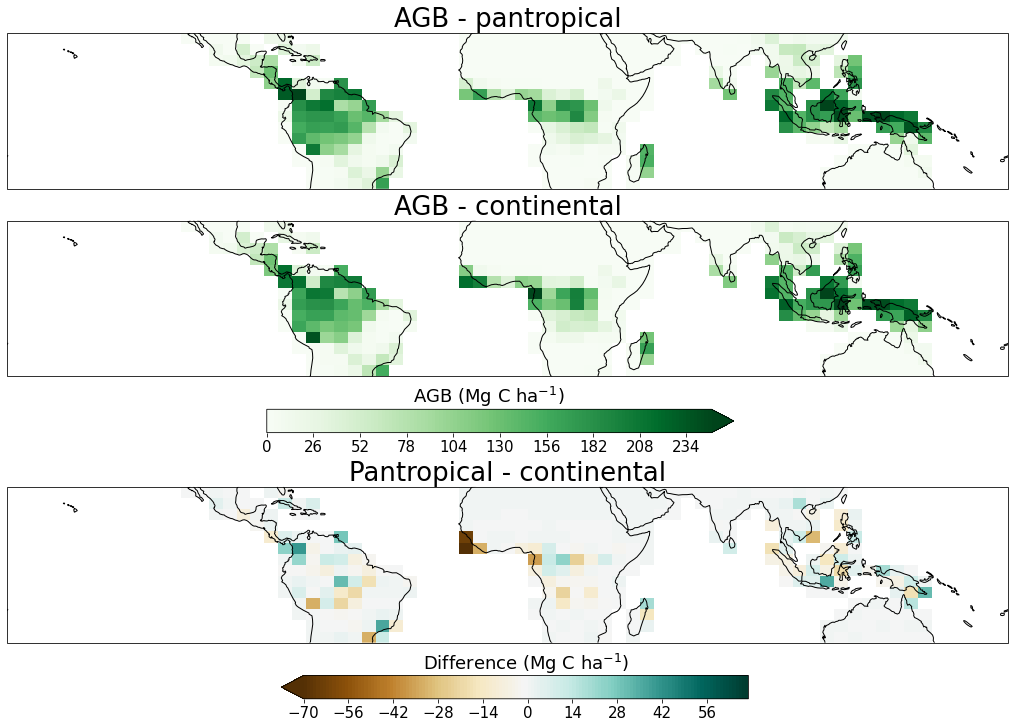

In [21]:
# Define the contour levels to use in plt.contourf
clevs=np.arange(0,250,2)
fig, axs = plt.subplots(nrows=3,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(18,10), constrained_layout=True)

axs = axs.flatten()

cs= agb_ctr.plot(levels=clevs,cmap='Greens', ax=axs[0],add_colorbar=False)
axs[0].set_title(r'AGB - pantropical', size=26)
axs[0].coastlines()

cs= agb.plot(levels=clevs,cmap='Greens', ax=axs[1],add_colorbar=False)
axs[1].set_title('AGB - continental', size=26)
axs[1].coastlines()

cbar = fig.colorbar(cs, ax=axs[1], location='bottom',shrink=0.6)
cbar.ax.set_title(r"AGB (Mg C ha$^{-1}$)", size=18)
cbar.ax.tick_params(labelsize=15) 

diff = agb_ctr - agb

clevs=np.arange(-70,70,1)
cs= diff.plot(levels=clevs,cmap='BrBG', ax=axs[2],add_colorbar=False)
axs[2].set_title('Pantropical - continental', size=26)
axs[2].coastlines()

cbar = fig.colorbar(cs, ax=axs[2], location='bottom',shrink=0.6)
cbar.ax.set_title(r"Difference (Mg C ha$^{-1}$)", size=18)
cbar.ax.tick_params(labelsize=15) 

### Regrid GEDI

In [22]:
agb_ctr = fates_ctr_tmp.FATES_VEGC_ABOVEGROUND.mean(dim='time') *  10
agb = fates_tmp.FATES_VEGC_ABOVEGROUND.mean(dim='time') *  10

In [23]:
gedi_agb_reproj = da.rio.reproject_match(agb_ctr)

In [24]:
gedi_agb_reproj.coords

Coordinates:
  * x            (x) float32 0.0 5.0 10.0 15.0 20.0 ... 340.0 345.0 350.0 355.0
  * y            (y) float32 -26.0 -22.0 -18.0 -14.0 ... 14.0 18.0 22.0 26.0
    band         int64 1
    spatial_ref  int64 0

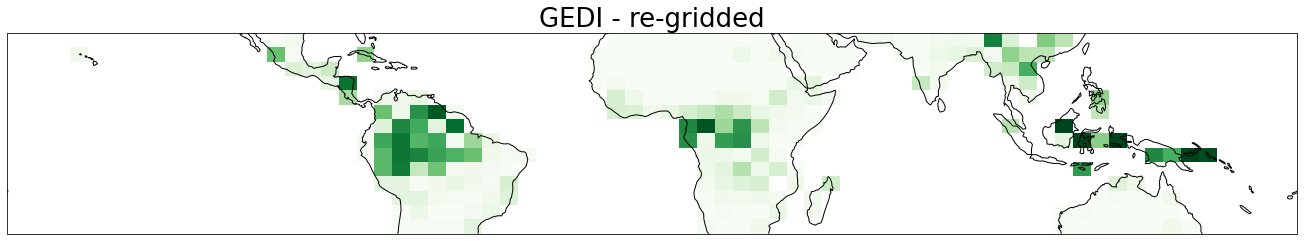

In [25]:
# Define the contour levels to use in plt.contourf
clevs=np.arange(0,300,5)
fig, axs = plt.subplots(nrows=1,ncols=1,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(18,4), constrained_layout=True)


cs= gedi_agb_reproj.plot(levels=clevs,cmap='Greens', ax=axs,add_colorbar=False)
axs.set_title('GEDI - re-gridded', size=26)
axs.coastlines()

In [26]:
diff  = gedi_agb_reproj - agb
diff_ctr = gedi_agb_reproj - agb_ctr

diff_agb_fates = agb_ctr - agb

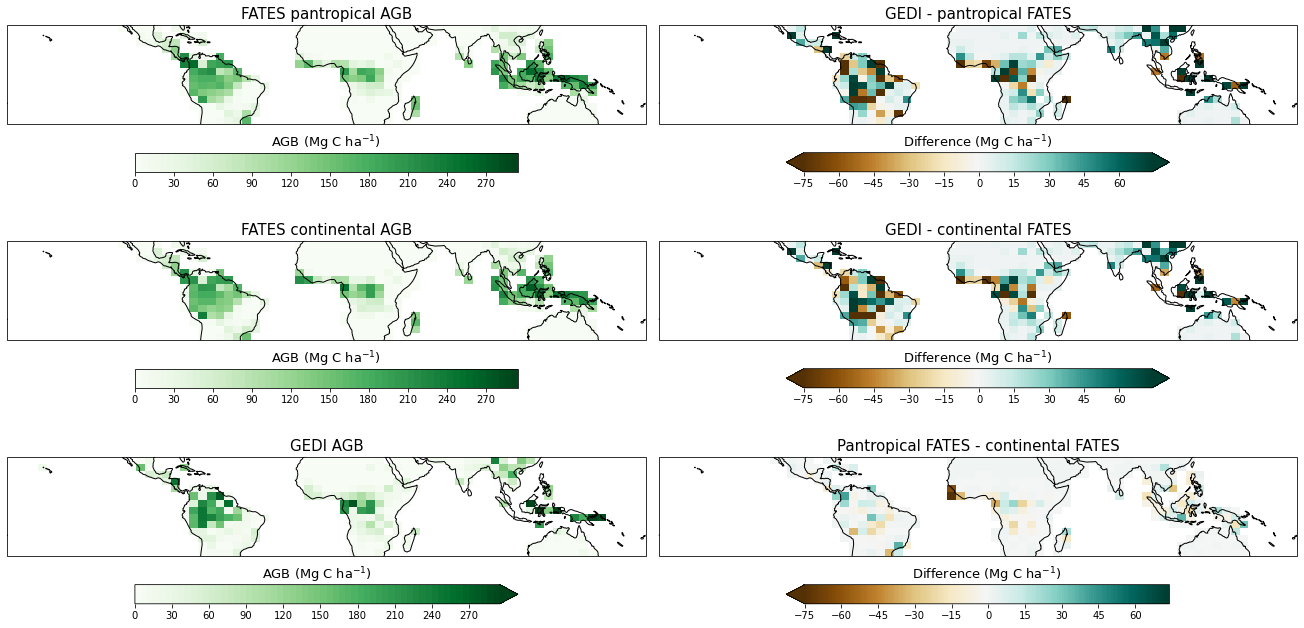

In [27]:
fig, axs = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        figsize=(18,9),constrained_layout=True)

clevs = np.arange(0.,300,5)
axs=axs.flatten()

cs = agb_ctr.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='Greens',
         ax=axs[0], add_colorbar=False)
axs[0].coastlines()
axs[0].set_title('FATES pantropical AGB', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[0], location='bottom',shrink=0.6)
cbar.ax.set_title(r"AGB (Mg C ha$^{-1}$)", fontsize=13)

cs = agb.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='Greens',
         ax=axs[2], add_colorbar=False)
axs[2].coastlines()
axs[2].set_title('FATES continental AGB', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[2], location='bottom',shrink=0.6)
cbar.ax.set_title(r"AGB (Mg C ha$^{-1}$)", fontsize=13)

cs = gedi_agb_reproj.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='Greens',
         ax=axs[4], add_colorbar=False)
axs[4].coastlines()
axs[4].set_title('GEDI AGB', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[4], location='bottom',shrink=0.6)
cbar.ax.set_title(r"AGB (Mg C ha$^{-1}$)", fontsize=13)

clevs = np.arange(-75,75,1)
cs = diff_ctr.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='BrBG',
         ax=axs[1], add_colorbar=False)
axs[1].coastlines()
axs[1].set_title('GEDI - pantropical FATES', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[1], location='bottom',shrink=0.6)
cbar.ax.set_title(r"Difference (Mg C ha$^{-1}$)", fontsize=13)


cs = diff.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='BrBG',
         ax=axs[3], add_colorbar=False)
axs[3].coastlines()
axs[3].set_title('GEDI - continental FATES', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[3], location='bottom',shrink=0.6)
cbar.ax.set_title(r"Difference (Mg C ha$^{-1}$)", fontsize=13)

cs = diff_agb_fates.plot(levels=clevs, transform=ccrs.PlateCarree(),cmap='BrBG',
         ax=axs[5], add_colorbar=False)
axs[5].coastlines()
axs[5].set_title('Pantropical FATES - continental FATES', fontsize=15)
cbar = fig.colorbar(cs, ax=axs[5], location='bottom',shrink=0.6)
cbar.ax.set_title(r"Difference (Mg C ha$^{-1}$)", fontsize=13)

plt.savefig('/global/homes/j/jneedham/tropical-fixed-biog/figs/GEDI_v_FATES_agb.png', 
            bbox_inches='tight', facecolor='white')
